# CryoET specimen generator

Builds a large, high-resolution cryoET specimen (proteins + membranes + filaments) in two steps:

1. **Placement** — `polnet` runs its non-overlapping, occupancy-driven packing entirely at a small, cheap low resolution (fast — avoids ever allocating full-tomogram-sized bookkeeping arrays at the target resolution).
2. **Rendering** — specter renders the real high-resolution density directly from those placements: one real atomic-scattering-potential map per protein species (`specter.potential.PotentialBuilder`), and an analytic bilayer reconstruction per membrane (fitted back from polnet's output mesh).

Scope for this first pass: cytosolic proteins + membranes (sphere/ellipsoid/toroid) only. Membrane-embedded proteins, ice/solvent filling, and TEM/IMOD simulation are not yet included — `polnet` is used purely for coordinate/rotation generation, its TEM code path is never touched.

Proteins are specified as plain **PDB codes** (e.g. `"1bxn"`) — fetched automatically from RCSB on first use and cached locally.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from specter.specimen.cryoet import CryoETSpecimenGenerator
from specter.specimen.filament import ACTIN_SPEC, MICROTUBULE_SPEC

## Configure the specimen

- `protein_specs`: one self-contained dict per protein species — only `"PDB_CODE"` is required, everything else (`PMER_OCC`, `PMER_L`, `PMER_L_MAX`, `PMER_OVER_TOL`, `MMER_ISO`) falls back to polnet's own defaults if omitted.
- `membrane_specs`: polnet `.mbs`-equivalent param dicts, same shape as `protein_specs` (one complete dict per species/population). `MB_TYPE` is `"sphere"`, `"ellipsoid"`, or `"toroid"` (ellipsoid uses `MB_MIN_AXIS`/`MB_MAX_AXIS`/`MB_MAX_ECC` instead of `MB_MIN_RAD`/`MB_MAX_RAD`).
- `filament_specs`: one dict per filament species, converted to a `filament.FilamentSpec` (`code`, `step`, `flex_deg`, `twist_deg`, `n_filaments`, `n_monomers`). Placed by specter's own random-walk code, not polnet -- no low-res placement pass. `MICROTUBULE_SPEC`/`ACTIN_SPEC` are ready-made presets (real tubulin-dimer/F-actin axial rise and helical twist); `dataclasses.asdict(...)` turns either into a spec dict, optionally overriding fields like `n_filaments`.
- `target_shape`/`target_v_size`: the real output volume you want, `(Z, Y, X)` voxels at the given Å/voxel.
- `low_res_v_size`: voxel size polnet uses for its placement pass (10 Å is a good default — fast, and the analytic membrane/rotation math doesn't care about this resolution at all).

This first run uses a modest target size so it finishes in well under a minute — scale `target_shape`/`target_v_size` up once you're happy with the result (see the note at the bottom for the full-size case).

In [ ]:
import dataclasses

protein_specs = [
    {"PDB_CODE": "1bxn", "PMER_OCC": 3.0},
    {"PDB_CODE": "5mac", "PMER_OCC": 2.0},
]

membrane_specs = [
    {
        "MB_TYPE": "sphere",
        "MB_THICK_RG": (
            25.0,
            35.0,
        ),  # bilayer thickness range, Å (polnet's own default)
        "MB_LAYER_S_RG": (
            0.5,
            2.0,
        ),  # per-leaflet Gaussian sigma range, Å (polnet's own default --
        # a real bilayer leaflet is only ~0.5-2 A "fuzzy". An earlier
        # version of this example used (8, 12), which made the membrane
        # look unrealistically soft at high resolution -- the reconstruction
        # was correctly blurring by whatever sigma it was told to use, the
        # example value itself was just too large.
        "MB_OCC_RG": (0.005, 0.01),  # target occupancy fraction range
        "MB_OVER_TOL": 0.5,  # allowed overlap fraction
        "MB_DEN_CF_RG": (0.3, 0.5),  # density contrast factor range
        "MB_MIN_RAD": 100.0,
        "MB_MAX_RAD": 300.0,
    },
    # Example ellipsoid membrane (uncomment to add):
    {
        "MB_TYPE": "ellipsoid",
        "MB_THICK_RG": (25.0, 35.0),
        "MB_LAYER_S_RG": (0.5, 2.0),
        "MB_OCC_RG": (0.003, 0.006),
        "MB_OVER_TOL": 0.5,
        "MB_DEN_CF_RG": (0.3, 0.5),
        "MB_MAX_ECC": 0.85,
        "MB_MIN_AXIS": 80.0,
        "MB_MAX_AXIS": 250.0,
    },
]

filament_specs = [
    {**dataclasses.asdict(MICROTUBULE_SPEC), "n_filaments": 2},
    {**dataclasses.asdict(ACTIN_SPEC), "n_filaments": 4},
]

gen = CryoETSpecimenGenerator(
    protein_specs=protein_specs,
    membrane_specs=membrane_specs,
    filament_specs=filament_specs,
    target_shape=(500, 1000, 1000),  # (Z, Y, X) voxels
    target_v_size=3.0,  # Å/voxel
    low_res_v_size=10.0,
    seed=11,
)

## Generate

Runs polnet's placement at low resolution, then renders the real high-resolution volume. Returns a `torch.Tensor`, specter-native axis order `(Z, Y, X)`.

In [13]:
import time

t0 = time.time()
volume = gen.generate()
print(f"generated in {time.time() - t0:.1f}s")
print(
    "shape:",
    tuple(volume.shape),
    "nonzero voxels:",
    int((volume > 0).sum()),
    "max:",
    float(volume.max()),
)

[cryoet] low-res placement: (300, 300, 150) voxels @ 10.0 A/vx, 2 protein species, 2 membrane spec(s)
Assemblies available: 1
1bxn: Fetching default Biological Assembly 1
File already exists: ../pdb-data/1bxn-assembly1.cif, skip fetching.


Extracting atom coordinates and element: 0it [00:00, ?it/s]

[cryoet]   1bxn: 36288 atoms, low-res placeholder built in 4.1s
Assemblies available: 1
5mac: Fetching default Biological Assembly 1
File already exists: ../pdb-data/5mac-assembly1.cif, skip fetching.


Extracting atom coordinates and element: 0it [00:00, ?it/s]

[cryoet]   5mac: 37866 atoms, low-res placeholder built in 5.0s
[cryoet] running polnet placement (membranes + protein packing)...


[20:48:54] INFO: Inserted 7 membranes of type 'sphere' with occupancy 0.8064 %.
[20:49:35] INFO: Inserted 7 membranes of type 'ellipsoid' with occupancy 0.5117 %.


[cryoet] polnet placement done in 54.9s
[cryoet] 622 protein instance(s) placed
[cryoet]   chain sizes (SAWLC): 1bxn: {1: 6, 2: 7, 3: 4, 4: 3, 5: 7, 6: 4, 7: 8, 8: 8, 9: 4, 10: 10, 11: 3}; 5mac: {1: 8, 2: 4, 3: 7, 4: 6, 5: 7, 6: 8, 7: 5, 8: 3, 9: 3}
[cryoet] 28 membrane instance(s) fitted
[cryoet] high-res assembly: (500, 1000, 1000) voxels @ 3.0 A/vx
[cryoet]   1bxn: high-res potential (50^3 @ 3.0 A/vx) built in 0.1s
[cryoet]   5mac: high-res potential (60^3 @ 3.0 A/vx) built in 0.1s
[cryoet] organic-matter potential reference: 9.97 (mean over-half-max value, averaged across 2 protein species -- used to calibrate membrane voxel values)
[cryoet] stamped 622 protein instance(s) in 6.5s
[cryoet] stamped 28 membrane instance(s) in 5.2s
generated in 76.3s
shape: (500, 1000, 1000) nonzero voxels: 73660607 max: 18.608198165893555


## Visualize

Central slices through each axis.

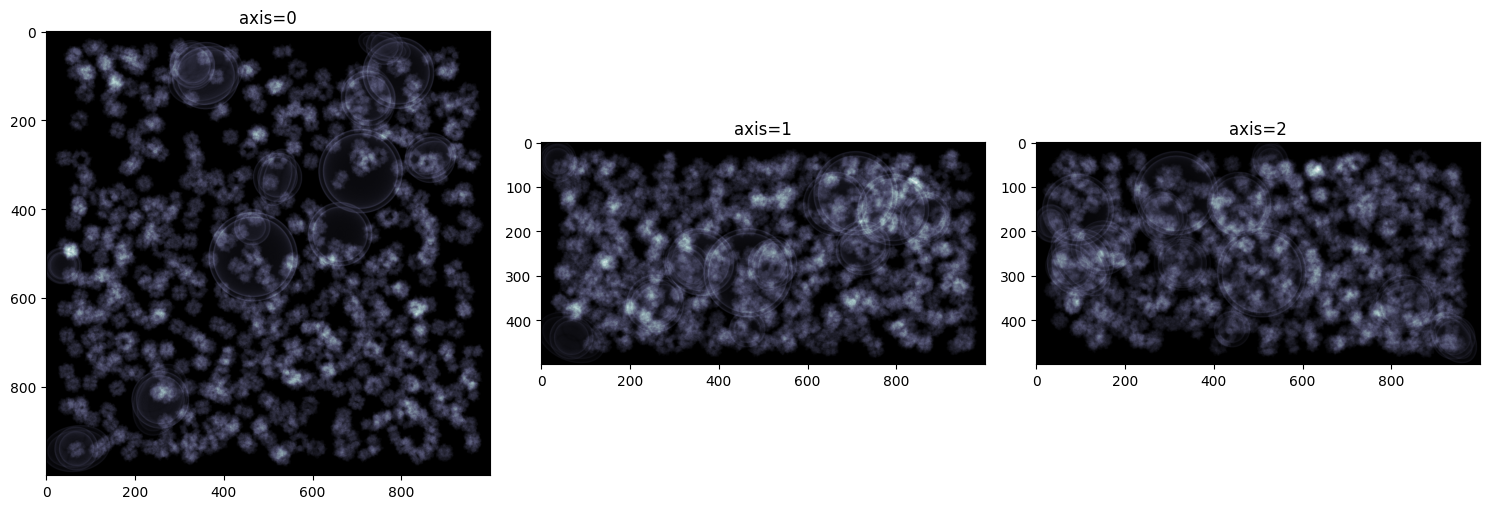

In [15]:
vol_np = volume.numpy()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, axis in zip(axes, [0, 1, 2]):
    ax.imshow(vol_np.sum(axis), cmap="bone")
    ax.set_title(f"axis={axis}")
plt.tight_layout()
plt.show()

## Inspect SAWLC chains

polnet places proteins as **chains** (self-avoiding worm-like-chain polymers), not independent scattered copies — monomers link to a growing chain's tail until a randomly-drawn max length is hit or placement fails. `gen.protein_instances` (populated after `generate()`) carries each instance's `polymer` index, so you can group by `(code, polymer)` to see chain membership directly (polymer indices are only unique *within* a species — each species gets its own chain-building network).

If chains all look like singletons, it's usually because the target occupancy (`PMER_OCC`, set per species in `protein_specs`) is too low for that species to place enough monomers for multi-member chains to show up, not because chaining isn't happening.

1bxn: chain sizes -> {1: 6, 2: 6, 3: 9, 4: 4, 5: 4, 6: 7, 7: 9, 8: 2, 9: 7, 10: 5, 11: 6}
5mac: chain sizes -> {1: 7, 2: 9, 3: 8, 4: 6, 5: 7, 6: 8, 7: 4, 8: 5, 9: 1}


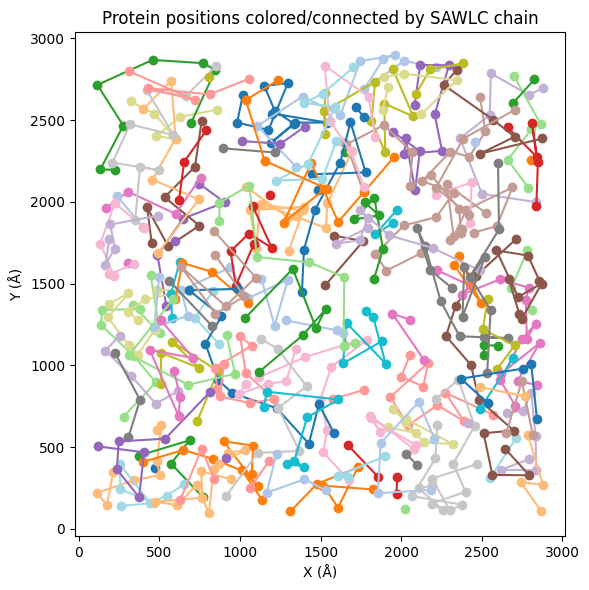

In [10]:
from collections import Counter

# Chain-length histogram per species: {chain_length: number_of_chains_with_that_length}
by_code = {}
for inst in gen.protein_instances:
    by_code.setdefault(inst.code, Counter())[inst.polymer] += 1
for code, counts in by_code.items():
    print(f"{code}: chain sizes -> {dict(sorted(Counter(counts.values()).items()))}")

# Scatter of protein positions (X vs Y), colored by chain -- points sharing a
# color/marker that are near each other and similarly oriented are one SAWLC chain.
fig, ax = plt.subplots(figsize=(6, 6))
for code, counts in by_code.items():
    chain_ids = sorted(counts)
    cmap = plt.get_cmap("tab20")
    for i, pid in enumerate(chain_ids):
        pts = np.array(
            [
                inst.position_xyz
                for inst in gen.protein_instances
                if inst.code == code and inst.polymer == pid
            ]
        )
        ax.plot(
            pts[:, 0], pts[:, 1], "o-", color=cmap(i % 20), label=f"{code} chain {pid}"
        )
ax.set_xlabel("X (Å)")
ax.set_ylabel("Y (Å)")
ax.set_title("Protein positions colored/connected by SAWLC chain")
plt.tight_layout()
plt.show()

## Inspect filaments

`gen.filament_instances` (populated after `generate()`) carries every placed monomer, one `FilamentInstance` per copy -- `code`, `filament_id` (which random-walk instance), `monomer_index` (position along it), `position_xyz`, `rotation_matrix`. Group by `(code, filament_id)` to recover one filament's own path, e.g. to check it looks like a smooth curve at the tuned `step`/`flex_deg`.

In [ ]:
by_filament_code = {}
for inst in gen.filament_instances:
    by_filament_code.setdefault(inst.code, {}).setdefault(inst.filament_id, []).append(
        inst
    )
for code_, filaments in by_filament_code.items():
    lengths = [len(monomers) for monomers in filaments.values()]
    print(f"{code_}: {len(filaments)} filament(s), monomer counts -> {lengths}")

# Plot one filament's monomer-center path (first species, first instance) to sanity-check
# the random-walk geometry -- should be a smooth, gently curving line, not jagged or straight.
first_code = next(iter(by_filament_code))
first_filament = by_filament_code[first_code][0]
path_xyz = torch.stack(
    [
        inst.position_xyz
        for inst in sorted(first_filament, key=lambda i: i.monomer_index)
    ]
)

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(path_xyz[:, 0], path_xyz[:, 1], "o-")
ax.set_xlabel("x (A)")
ax.set_ylabel("y (A)")
ax.set_title(f"{first_code} filament 0 path (xy projection)")
ax.set_aspect("equal")
plt.show()

## Save

Volume is specter-native `(Z, Y, X)`, which is also raw-mrcfile's native storage order — no axis swap needed on save.

In [6]:
# out_path = "cryoet_specimen.mrc"
# with mrcfile.new(out_path, overwrite=True) as f:
#     f.set_data(vol_np.astype(np.float32))
#     f.voxel_size = gen.target_v_size
# print("saved to", out_path)

## Notes for scaling up

- **Full production size** (e.g. `target_shape=(1000, 4000, 4000)` at 1–2 Å/voxel): the mechanism doesn't change, but that's ~64 GB at float32 — write the output as a memory-mapped array/MRC rather than an in-RAM tensor before attempting it (see the plan notes; `_insert_clipped` in `cryoet.py` only ever touches small local slices, so a memmap backing store drops in without other changes).
- **Membrane voxel-value calibration**: membrane density is calibrated to the *actual protein templates built for this specimen* — proteins and lipid bilayers are both ordinary, densely-packed organic matter (C/H/N/O), so a membrane's typical scattering potential should be roughly comparable in magnitude to a protein's, not an arbitrary unit. Concretely: `_estimate_organic_potential_reference()` takes the mean potential over each protein template's own "occupied" voxels (≥ half that template's peak), averaged across species, then each membrane spec's `MB_DEN_CF_RG` (polnet's own density-contrast-factor range, drawn once per spec) modulates it down from there — e.g. `reference≈16.5, cf∈(0.3,0.5)` gives membrane peaks around 5–8, distinguishable from but on the same physical scale as the ~16.5-magnitude protein interior. `membrane_potential_scale` remains available as a manual fine-tuning multiplier on top (default 1.0 = no adjustment), and as the sole lever if no proteins are placed at all (nothing to calibrate against). Still an approximation — lipid composition/packing isn't identical to protein — but no longer an arbitrary constant.
- **Not yet in scope**: membrane-embedded/anchored proteins. Ice/solvent filling is *not* done by `CryoETSpecimenGenerator` itself (this class only places proteins + membranes), but `TiltSeriesGenerator`/`MicrographGenerator` can blend ice into its output directly via `vol=` + `ice_model=`/`icemaker=` -- see the next section.
- **Known narrow edge case**: membranes configured to physically touch/overlap (`MB_OVER_TOL` allowing it) may fuse into one connected component when fitting per-membrane parameters back out of polnet's mesh, and fit incorrectly as a single blended shape. Rare — only matters if you intentionally configure overlapping membranes.

## Feed into imaging (add ice)

`TiltSeriesGenerator` and `MicrographGenerator` accept this particles+membranes `volume` directly via `vol=`. If `ice_model=` (`'gd'` for the production-quality `IceBank` cache, or `'random'` for a fast/cheap smoke test) or a pre-built `icemaker=` is also given, ice is generated to match `vol`'s own size and voxel size and blended in wherever `vol` has little existing scattering potential -- the same masking rule the single-particle generators use -- so it fills the space around the placed proteins/membranes without overwriting them. This happens once, at construction time, before `TiltSeriesGenerator`'s own tilt-coverage/taper padding is applied.

Not executed here (the volume above is full production scale); illustrates the pattern for a `(1, Z, Y, X)`-shaped `vol` at the specimen's own pixel size.


In [ ]:
# from specter.imagegenerator import TiltSeriesGenerator
#
# tilt_series_gen = TiltSeriesGenerator(
#     vol=volume.unsqueeze(0),  # TiltSeriesGenerator expects (1, Z, Y, X)
#     micrograph_size=800,
#     pixel_size=gen.target_v_size,
#     ctf_params=ctf_params,
#     voltage=300.0,
#     dose_per_angstrom=3.0,
#     angles=torch.linspace(-60, 60, 41),
#     ice_model="gd",  # or "random" for a fast/cheap smoke test
# )
# tilt_series, _, _ = tilt_series_gen.generate_tilt_series(torch.tensor([0]))
